In [43]:
# This file is to perform looser EDA before compiling results
# in eda.py.

import data

# Load in the data using the make_data function without removing
# labels. Don't save patches since it is just based on the images
# and not relevant to cleaning and EDA.
images_long, _ = data.make_data(remove_labels=False)

100%|██████████| 164/164 [00:07<00:00, 23.21it/s]


In [44]:
import numpy as np

# Are there are any NANs in the images?
print("How many NaN's in the images?: " \
      f"{sum([sum(sum(np.isnan(images_long[i]))) for i in range(164)])}")

How many NaN's in the images?: 0


In [45]:
# Make a list of the names of the radiance angles
rad_angles = ["DF", "CF", "BF", "AF", "AN"]

# Make a list of the synthetic features.
syn_ftrs = ["NDAI", "SD", "CORR"]

# Make a list of the names of the main features.
ftrs = (["y", "x"]
        + syn_ftrs
        + ["Radiance Angle " + ang for ang in rad_angles] + ["Expert Label"])

# Set the length of images_long (164) to a constant.
im_count = len(images_long)

# Count the total number of pixels.
pix_count = sum([len(images_long[im]) for im in range(im_count)])

# Initialize a dictionary to store the zero percentages.
zero_per = {}

# Initialize a dictionary to store the index (and percentage) of the 
# image with the maximum percentage of zeros in each feature.
zero_ftr_max = {}

# Initialize a dictionary to store concatenated numpy arrays of
# each feature across all images.
pixel_dict = {}

for idx, ftr in enumerate(ftrs):
    # Concatenate all the numpy arrays tied to the feature
    # and store the result. For the unlabeled images, impute NaN's
    # in the expert label feature.
    pixel_dict[ftr] = np.concatenate([images_long[im][:,idx]
                                      if idx < images_long[im].shape[1] 
                                      else np.array([np.nan] * len(images_long[im]))
                                      for im in range(im_count)])
    
    # If this feature is the expert label, continue the loop
    # since we don't want to do the zero-based analysis on a 
    # trivially, mostly zero feature.
    if idx == len(ftrs) - 1:
        continue

    # Store the percent of zeros in each feature throughout all 
    # the images
    zero_per[ftr] = 100 * (1 - sum([np.count_nonzero(images_long[im][:,idx]) 
                                    for im in range(im_count)]) / pix_count)
    
    # Make a list of the percent of zeros for the given feature
    # by image.
    zero_im_lst = [100 * (1 - np.count_nonzero(images_long[im][:,idx]) /
                len(images_long[im][:,idx])) for im in range(im_count)]
    
    # Store the image (and percentage) with the maximum percentage
    # of zeros in each feature
    max_per = max(zero_im_lst)
    zero_ftr_max[ftr] = (zero_im_lst.index(max_per), max_per)

# Add key-value pair to pixel_dict to store the original image index
# of each.
pixel_dict["Image"] = np.concatenate([np.array([im] * len(images_long[im])) 
                                      for im in range(im_count)])

# Print the dictionaries.
print("Percent of zeros across all images for each feature:")
print(f"{zero_per}\n")
print("Index (and percentage) of image with maximum percentage of zeros " \
    "for each feature:")
print(f"{zero_ftr_max}\n")

Percent of zeros across all images for each feature:
{'y': 0.0, 'x': 0.0, 'NDAI': 8.978258829728247e-05, 'SD': 0.0, 'CORR': 0.0002270971350970541, 'Radiance Angle DF': 0.0, 'Radiance Angle CF': 0.0, 'Radiance Angle BF': 0.0, 'Radiance Angle AF': 0.0, 'Radiance Angle AN': 0.0}

Index (and percentage) of image with maximum percentage of zeros for each feature:
{'y': (0, 0.0), 'x': (0, 0.0), 'NDAI': (15, 0.0008670319761372447), 'SD': (0, 0.0), 'CORR': (93, 0.0017323966841953364), 'Radiance Angle DF': (0, 0.0), 'Radiance Angle CF': (0, 0.0), 'Radiance Angle BF': (0, 0.0), 'Radiance Angle AF': (0, 0.0), 'Radiance Angle AN': (0, 0.0)}



<Figure size 640x500 with 0 Axes>

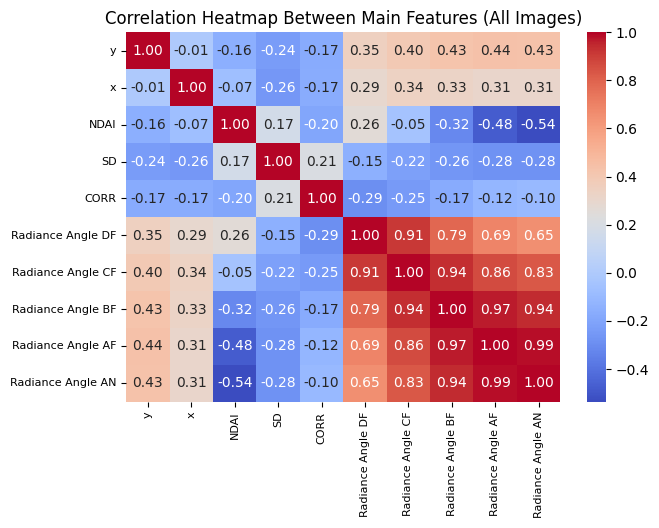

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construct pandas dataframe from the dictionary using the features 
# as columns and all the pixels throughout all the images as rows.
pixel_df = pd.DataFrame(pixel_dict)

# Exclude expert labels and image indexes when making heatmap.
pixel_df_unlabeled = pixel_df.drop(columns=["Expert Label", "Image"])

# Make a correlation heatmap (we don't need to set numeric_only in 
# corr to True since every entry in pixel_df_unlabeled is numeric anyway), 
# rounding the displayed correlations to 2 decimal places.
sns.heatmap(pixel_df_unlabeled.corr(), cmap="coolwarm", fmt=".2f", annot=True)

# Add a title to the plot.
plt.title("Correlation Heatmap Between Main Features (All Images)")

# Change size of x and y ticks since they are too big by default.
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Show the heatmap.
plt.show()

In [47]:
# Now, let's work with the expert labeled images.

# Filter the data frame just to the labeled images.
labeled_df = pixel_df[pixel_df["Expert Label"].notna()]

# List labeled image indexes.
labeled_idx = labeled_df["Image"].unique()

# List true MISR image numbers.
misr_im_num = [12791, 13257, 13490]

# Make a dictionary mapping the labeled indexes to the true MISR
# image numbers.
labeled_im_name_map = dict([(k, v) for k, v in zip(labeled_idx, misr_im_num)])

# Split the labeled data frame into each of the three labeled images.
labeled_images = [labeled_df[labeled_df["Image"] == labeled_idx[im]]
                  for im in range(len(labeled_idx))]


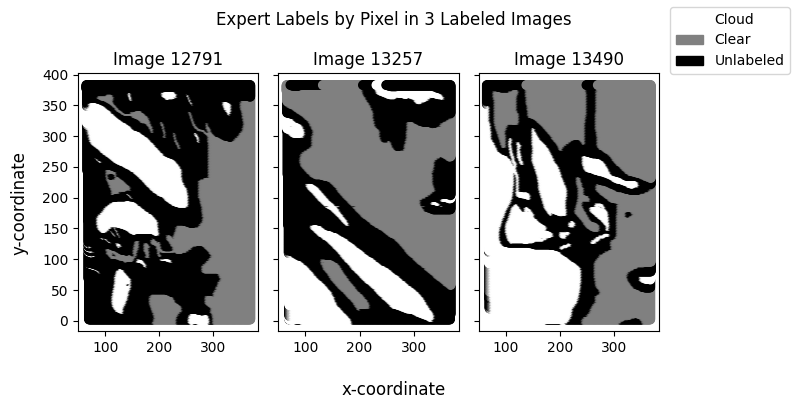

In [48]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Make a colormap for the expert labels matching Yu 2008.
cmap = mcolors.ListedColormap(["gray", "black", "white"])

# Make a 1 x 3 grid of subplots.
fig, axs = plt.subplots(1, 3, figsize=(8, 4), sharex=True, sharey=True)

# For each image, plot the expert labels for the presence or
# absence of clouds in each images according to a map 
# (i.e. use the X, Y coordinates).
for im in range(len(labeled_images)):
    axs[im].scatter(x=labeled_images[im]["x"], y=labeled_images[im]["y"], 
                        c=labeled_images[im]["Expert Label"],
                        cmap=cmap)
    
    # Set name of each subplot to be MISR number of image.
    axs[im].set_title(f"Image {labeled_im_name_map[labeled_idx[im]]}")
    
# Make shared axis labels as the x- and y-coordinates and
# an overall title.
fig.supxlabel("x-coordinate")
fig.supylabel("y-coordinate")
fig.suptitle("Expert Labels by Pixel in 3 Labeled Images")
    
# Add legend handles to make color legend for entire plot.
legend_handles = [
    mpatches.Patch(color="white", label="Cloud"),
    mpatches.Patch(color="gray", label="Clear"),
    mpatches.Patch(color="black", label="Unlabeled"),
]

# Use legend_handles to make legend for full figure.
fig.legend(handles=legend_handles, loc="outside right upper")

# Use tight layout to avoid overlap, using 15 percent of
# the space on the right for the legend, and show the plot.
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

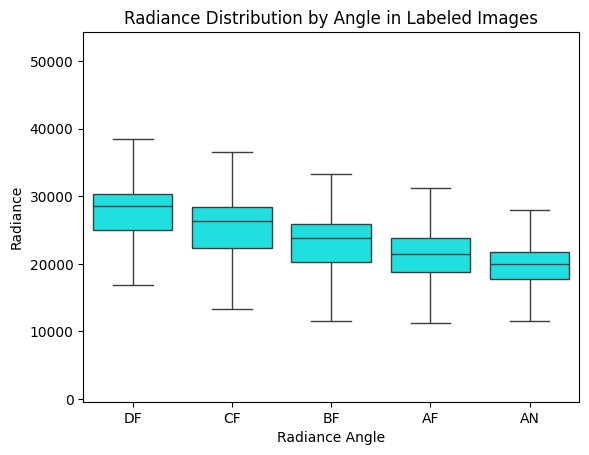

In [49]:
# Now, let's look at the radiances.

# Make a list of radiance features.
rad_ftrs = [ftr for ftr in ftrs if "Radiance" in ftr]

# Filter the labeled dataframe just for the 
# radiance features.
rad_df = labeled_df[rad_ftrs]

# Change the column names to get rid of the redundant
# "Radiance Angle" at the start.
rad_df.columns = rad_df.columns.str.removeprefix("Radiance Angle ")

# Make a boxplot of the radiance features.
sns.boxplot(data=rad_df, fliersize=0, 
            color="cyan")
plt.xlabel("Radiance Angle")
plt.ylabel("Radiance")
plt.title("Radiance Distribution by Angle in Labeled Images")

# Display the plot.
plt.show()

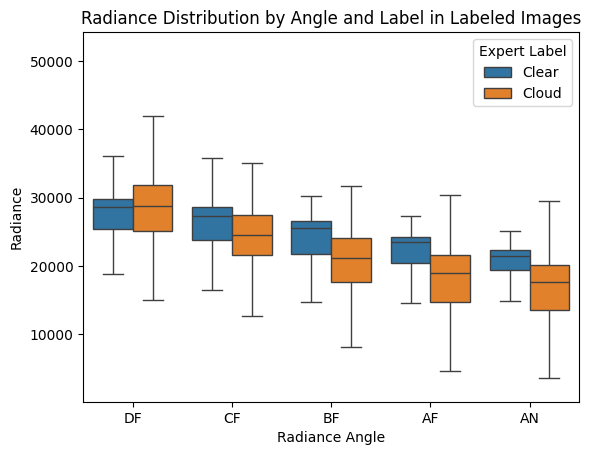

In [50]:
# Get rid of SettingWithCopyWarning I deal with later.
pd.options.mode.chained_assignment = None

# Next, drop the unlabeled pixels from the labeled dataframe.
tot_labeled_df = labeled_df[labeled_df["Expert Label"] != 0]

# Recode the labels as Cloud and Clear.
tot_labeled_df["Expert Label"] = tot_labeled_df["Expert Label"].replace({
    1: 'Cloud',
     -1: 'Clear'
})

# Regenerate radiance dataframe with only labeled pixels
# but keep labels this time.
rad_df_tot_lab = tot_labeled_df[rad_ftrs + ["Expert Label"]]

# Change the column names to get rid of the redundant
# "Radiance Angle" at the start.
rad_df_tot_lab.columns = \
    rad_df_tot_lab.columns.str.removeprefix("Radiance Angle ")

# Make a boxplot of the radiance features separated by
# cloud label status, using a long format version of the 
# dataframe as required by the boxplot function.
sns.boxplot(data=rad_df_tot_lab.melt(id_vars=["Expert Label"], 
                                     value_vars=rad_angles, 
                                     var_name="Radiance Angle",
                                     value_name="Radiance"),
                                     x="Radiance Angle",
                                     y="Radiance",
                                     fliersize=0, 
                                     hue="Expert Label")

# Add x and y axes and title.
plt.xlabel("Radiance Angle")
plt.ylabel("Radiance")
plt.title("Radiance Distribution by Angle and Label in Labeled Images")

# Display the plot.
plt.show()


In [51]:
from scipy.stats import ttest_ind
# Now, let's repeat this analysis for the features CORR, SD, and NDAI.

# Generate synthetic feature dataframe with only labeled pixels and keep
# labels.
syn_df_tot_lab = tot_labeled_df[syn_ftrs + ["Expert Label"]]

# Split the dataframe based on expert label.
syn_df_cloud = syn_df_tot_lab[syn_df_tot_lab["Expert Label"] == "Cloud"]
syn_df_clear = syn_df_tot_lab[syn_df_tot_lab["Expert Label"] == "Clear"]

# Initialize a dictionary to store tuples of mean differences and p-values
# for t-tests of independence when comparing CORR, SD, and NDAI 
# between cloud and clear expert labeled pixels.
diff_and_p_val_dict = {}

# Perform t-tests to compare CORR, SD, and NDAI between cloud and clear
# labeled pixels. Also calculate mean differences (cloud - clear)
# and add them both to dictionary.
# Round mean difference to 5 decimal places and convert p-values to
# scientific notation rounded to 5 decimal places.
for syn_ftr in syn_ftrs:
    # Calculate mean difference and p-value.
    mean_diff = "{:.5f}".format(syn_df_cloud[syn_ftr].mean()
                      - syn_df_clear[syn_ftr].mean())
    p_val = ttest_ind(syn_df_cloud[syn_ftr], syn_df_clear[syn_ftr]).pvalue
    
    # If p-value is just 0, impute it as 0 rather than 0.00000e+0,
    # which is redundant.
    if p_val != 0:
        p_val = '{:0.5e}'.format(p_val)
    
    # Add both mean difference and p value to dictionary.
    diff_and_p_val_dict[syn_ftr] = (mean_diff, p_val)


# Print mean differences and p-values.
print("Difference in means between cloud and clear labeled groups for each " \
     + "synthetic feature (cloud - clear):")
for syn_ftr in syn_ftrs:
    print(f"{syn_ftr}: {diff_and_p_val_dict[syn_ftr][0]}")

print("P-values for t-tests comparing synthetic features between cloud " \
      + "and clear labeled groups")
for syn_ftr in syn_ftrs:
    print(f"{syn_ftr}: {diff_and_p_val_dict[syn_ftr][1]}")

Difference in means between cloud and clear labeled groups for each synthetic feature (cloud - clear):
NDAI: 0.12188
SD: 559.97864
CORR: 0.04678
P-values for t-tests comparing synthetic features between cloud and clear labeled groups
NDAI: 0.0
SD: 0.0
CORR: 3.99032e-143


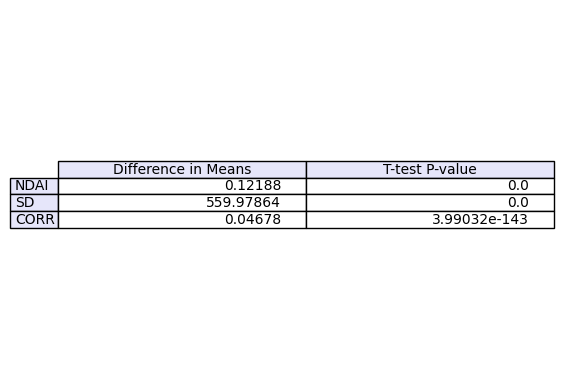

In [52]:
# Convert dictionary to pandas dataframe, transposing to make
# synthetic features be the rows.
diff_and_pval_df = pd.DataFrame(diff_and_p_val_dict).T

# Change column names.
diff_and_pval_df.columns = ["Difference in Means", "T-test P-value"]

# Turn off axes and border.
fig, axs = plt.subplots(1, 1)
axs.axis("tight")
axs.axis("off")

# Choose row and column colors.
color = "lavender"

# Make table.
plt.table(diff_and_pval_df, loc="center",
          colColours=[color] * diff_and_pval_df.shape[1],
          rowColours=[color] * diff_and_pval_df.shape[0],
          )

In [42]:
from sklearn.model_selection import train_test_split

COORDS = ["y", "x"]

# Set random state to 1.
random_state = 1

# Initialize a list of lists to store all the splits.
splits_by_im = []

# Iterate through expert labeled images and do the same to each.
for im in labeled_df["Image"].unique():
    # Randomly split labeled_df into 80/20 train/test split.
    tt_split = train_test_split(tot_labeled_df[tot_labeled_df["Image"] == im], 
                                train_size=0.8,
                                random_state=random_state)

    # Split training set into new training set and validation set with
    # 80/20 split.
    tv_split = train_test_split(tt_split[0], train_size=0.75,
                                random_state=random_state)

    # Combine results to get 60/20/20 train/val/test split.
    splits_by_im.append([tv_split[0], tv_split[1], tt_split[1]])

# Combine results across the expert labeled images.
all_splits = [pd.concat([splits_by_im[im][split]
                         for im in range(len(splits_by_im))])
                         for split in range(len(splits_by_im[0]))]

# Drop image and coordinate labels from all three splits to 
# avoid training upon them, as long as they are in the splits
# in the first place.
drop_list = ["Image"] + COORDS
drop_list = list(filter(lambda x: x in all_splits[0].columns, drop_list))
all_splits = [df.drop(columns=["Image"] + COORDS) 
                for df in all_splits]

# Make a list to store the X and y splits.
xy_splits = []

# Iterate through the splits, split them into X and y (i.e., features
# and label), and append the results to xy_splits.
for im in range(len(labeled_df["Image"].unique())):
    xy_splits.append(all_splits[im].iloc[:, :-1])
    xy_splits.append(all_splits[im].iloc[:, -1:])